In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style='whitegrid')

In [2]:
# Разбивка данных

data = fetch_california_housing()
print(data.keys())

X = pd.DataFrame(data.data, columns=data.feature_names)
display(X.head())
y = data.target

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Размер обучающей выборки: {X_train.shape[0]}')
print(f'Размер валидационной выборки: {X_val.shape[0]}')
print(f'Размер тестовой выборки: {X_test.shape[0]}')

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


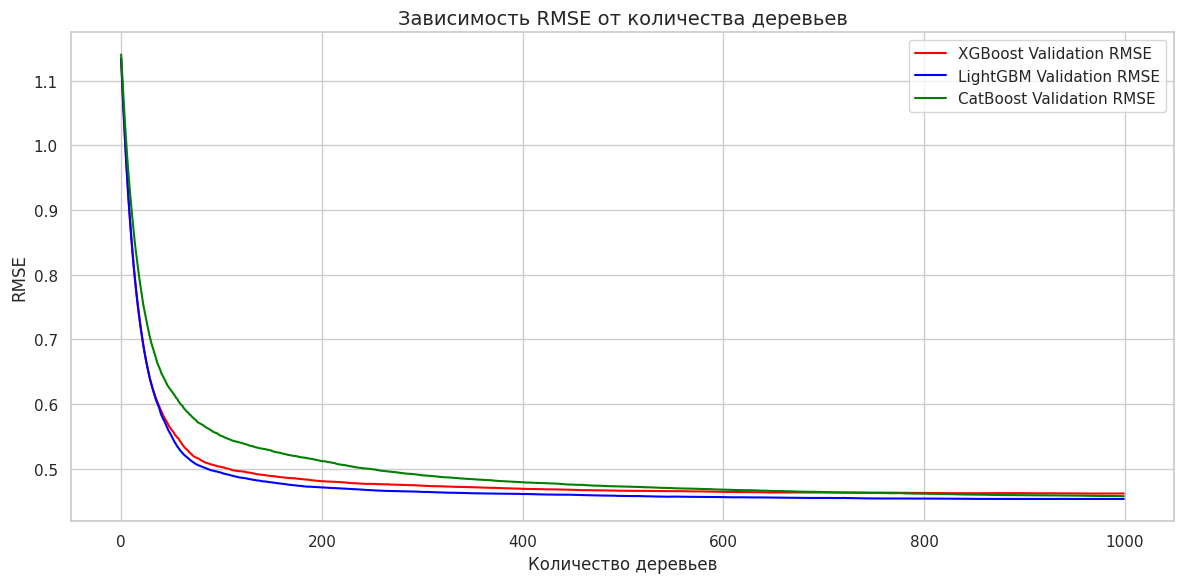

In [3]:
# Обучение и сравнение моделей

MAX_tree = 1000
Learning_rate = 0.05

xgb_model = xgb.XGBRegressor(n_estimators = MAX_tree, learning_rate = Learning_rate, random_state = 42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose= False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_tree, learning_rate=Learning_rate, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_tree, learning_rate=Learning_rate, eval_metric='RMSE', random_seed=42,
                                allow_writing_files=False)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']


plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label = 'XGBoost Validation RMSE', color = 'red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
SELECTED_N_ESTIMATORS = 400

In [5]:
# Создание своей модели
class MyBoost:
  def __init__(self, n=400, lr=0.05, depth=7, seed=42) -> None:
      self.n = n
      self.lr = lr
      self.depth = depth
      self.seed = seed
      self.trees = []

  def fit(self, X, y):
    self.initial_leaf = y.mean()
    predictions = np.zeros(len(y)) + self.initial_leaf

    for _ in range(self.n):
      antigrad = y - predictions
      tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse")

      tree.fit(X, antigrad)
      self.trees.append(tree)

      predictions += tree.predict(X) * self.lr

  def predict(self, samples):
    predictions = np.zeros(len(samples)) + self.initial_leaf
    for i in range(self.n):
      predictions += self.lr * self.trees[i].predict(samples)

    return predictions

In [6]:
# Поиск лучших параметов для моделей

from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grib_search(model_name, param_grid):
    print(f'--- Запуск Grid Search для {model_name} ---')
    best_rmse = float('inf')
    best_params = None

    start_time =  time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators= SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators= SELECTED_N_ESTIMATORS, random_state= 42, n_jobs = -1, verbose = -1)
        else:
            model = cb.CatBoostRegressor(**params, iterations= SELECTED_N_ESTIMATORS, random_seed= 42, thread_count= 42, verbose= 0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    
    total_time = time.time() - start_time
    print(f'Лучшый RMSE для {model_name}: {best_rmse:.4f}')
    print(f'Лучшие параметры для {model_name}: {best_params}')
    print(f'Затраченное время: {total_time:.2f} сек.\n')

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grib_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grib_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grib_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучшый RMSE для XGBoost: 0.4621
Лучшие параметры для XGBoost: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}
Затраченное время: 7.69 сек.

--- Запуск Grid Search для LightGBM ---
Лучшый RMSE для LightGBM: 0.4557
Лучшие параметры для LightGBM: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}
Затраченное время: 7.43 сек.

--- Запуск Grid Search для CatBoost ---
Лучшый RMSE для CatBoost: 0.4564
Лучшие параметры для CatBoost: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}
Затраченное время: 9.22 сек.



In [7]:
# Улучшенная моя модель
class MyBoost1:
  def __init__(self, n=400, lr=0.05, depth=7, seed=42, subsample = 1.0, colsample_bytree = 1.0, cat_features = None) -> None:
      self.n = n
      self.lr = lr
      self.depth = depth
      self.seed = seed
      self.subsample = subsample
      self.colsample_bytree = colsample_bytree
      self.cat_features = cat_features if cat_features else []
      self.cat_mappings = {}
      self.trees = []

  def fit(self, X, y):
    X = np.array(X)
    y = np.array(y)
    self.n_features_in_ = X.shape[1]

    for col_idx in self.cat_features:
        unique_cats = np.unique(X[:, col_idx])
        mapping = {}
        for cat in unique_cats:
            mapping[cat] = y[X[:, col_idx] == cat].mean()
        
        self.cat_mappings[col_idx] = mapping
        
        for cat, val in mapping.items():
            X[X[:, col_idx] == cat, col_idx] = val
    X = X.astype(float)


    self.initial_leaf = y.mean()
    predictions = np.zeros(len(y)) + self.initial_leaf
    np.random.seed(self.seed)

    for _ in range(self.n):
      antigrad = y - predictions

      n_samples = len(X)
      size = int(n_samples * self.subsample)
      indices =  np.random.choice(n_samples, size=size, replace = False)

      n_features = X.shape[1]
      col_size = int(n_features * self.colsample_bytree)
      col_indices = np.random.choice(n_features, size = col_size, replace = False)
      X_sub = X[indices][:, col_indices]
      antigrad_sub = antigrad[indices]

      tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse")

      tree.fit(X_sub, antigrad_sub)
      self.trees.append((tree, col_indices))

      predictions += tree.predict(X[:, col_indices]) * self.lr

  def predict(self, samples):
    samples = np.array(samples, copy=True)
    for col_idx, mapping in self.cat_mappings.items():
        for cat, val in mapping.items():
            samples[samples[:, col_idx] == cat, col_idx] = val
    samples = samples.astype(float)

    predictions = np.zeros(len(samples)) + self.initial_leaf
    for i in range(self.n):
      tree, col_indices = self.trees[i]
      predictions += self.lr * tree.predict(samples[:, col_indices])

    return predictions
  
  def get_feature_importances(self):
    importances = np.zeros(self.n_features_in_)

    for tree, col_indices in self.trees:
      importances[col_indices] += tree.feature_importances_

    return importances/ len(self.trees)
      


In [8]:
# Тест улучшенной модели
my_model = MyBoost1(subsample=0.8, colsample_bytree=0.8)
my_model.fit(X_train_full, y_train_full)

my_pred = my_model.predict(X_test)

my_mae = mean_absolute_error(y_test, my_pred)
my_rmse = np.sqrt(mean_squared_error(y_test, my_pred))
my_r2 = r2_score(y_test, my_pred)

print('MAE у улучшенной модели: ', round(my_mae, 4))
print('RMSE у улучшенной модели: ', round(my_rmse, 4))
print('R2 у улучшенной модели: ', round(my_r2, 4))

importances = my_model.get_feature_importances()
feature_names = data.feature_names

fi_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

print("\nТоп важных признаков:")
print(fi_df)



MAE у улучшенной модели:  0.2925
RMSE у улучшенной модели:  0.4475
R2 у улучшенной модели:  0.8472

Топ важных признаков:
      Признак  Важность
0      MedInc  0.172328
7   Longitude  0.150365
6    Latitude  0.143950
5    AveOccup  0.137797
2    AveRooms  0.118618
3   AveBedrms  0.104442
4  Population  0.100506
1    HouseAge  0.071993


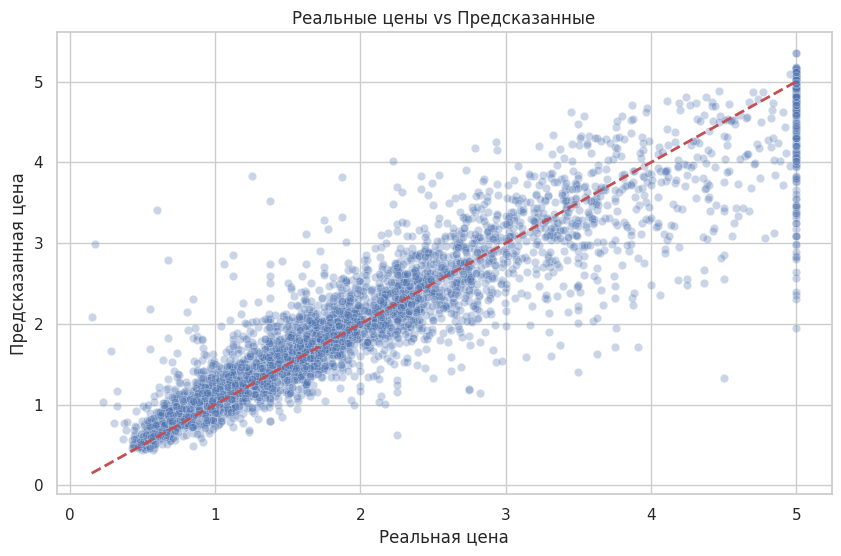

In [9]:
# Визуализация ошибок
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=my_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Реальные цены vs Предсказанные')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.show()


In [12]:
# Рузльтаты работы  всех моделей на тестовых данных

result = []

for name in['XGBoost', 'LightGBM', 'CatBoost', 'MyBoost', 'MyNewBoost']:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators = SELECTED_N_ESTIMATORS, random_state = 42, n_jobs = -1,  **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators= SELECTED_N_ESTIMATORS, random_state= 42, n_jobs= -1, verbose = -1, **params)
    elif name == 'MyBoost':
        model = MyBoost()
    elif name == 'MyNewBoost':
        model = MyBoost1(subsample=0.8, colsample_bytree=0.8)
    else:
        model = cb.CatBoostRegressor(iterations= SELECTED_N_ESTIMATORS, random_seed= 42, thread_count= -1, verbose= 0, **params)
    
    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time()-start_time

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    
    result.append({
        'model': name,
        'mae': round(mae, 4),
        'rmse': round(rmse, 4),
        'r2': round(r2, 4),
        'time': round(train_time, 2)
    })

df_result = pd.DataFrame(result)
display(df_result)







,model,mae,rmse,r2,time
0,XGBoost,0.2912,0.4476,0.8471,1.58
1,LightGBM,0.2862,0.4379,0.8537,0.45
2,CatBoost,0.2967,0.4493,0.8460,1.51
3,MyBoost,0.2955,0.4564,0.8410,34.75
4,MyNewBoost,0.2925,0.4475,0.8472,21.58
